<a href="https://colab.research.google.com/github/GarvinAgweli/Housepricingprediction/blob/personal/EXAM_SCORE_Analysis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
from sklearn.model_selection import train_test_split,StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold,GridSearchCV
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score,classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import  precision_recall_curve, average_precision_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import xgboost as xgb
import statsmodels.api as sm
import pickle
import gc
from sklearn import svm


In [3]:
df=pd.read_csv('student_exam_scores.csv')

In [4]:
df.head()

,student_id,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
0,S001,8.0,8.8,72.1,45,30.2
1,S002,1.3,8.6,60.7,55,25.0
2,S003,4.0,8.2,73.7,86,35.8
3,S004,3.5,4.8,95.1,66,34.0
4,S005,9.1,6.4,89.8,71,40.3


In [5]:
df.shape

(200, 6)

In [7]:
df.columns

Index(['student_id', 'hours_studied', 'sleep_hours', 'attendance_percent',
       'previous_scores', 'exam_score'],
      dtype='object')

In [6]:
df.describe()

,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,6.325500,6.622000,74.830000,66.800000,33.955000
std,3.227317,1.497138,14.249905,15.663869,6.789548
min,1.000000,4.000000,50.300000,40.000000,17.100000
25%,3.500000,5.300000,62.200000,54.000000,29.500000
50%,6.150000,6.700000,75.250000,67.500000,34.050000
75%,9.000000,8.025000,87.425000,80.000000,38.750000
max,12.000000,9.000000,100.000000,95.000000,51.300000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   student_id          200 non-null    object 
 1   hours_studied       200 non-null    float64
 2   sleep_hours         200 non-null    float64
 3   attendance_percent  200 non-null    float64
 4   previous_scores     200 non-null    int64  
 5   exam_score          200 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 9.5+ KB


In [10]:
# Check for missing values
print('Missing values in each column:')
print(df.isnull().sum())

# Convert data types if necessary and infer date types
# In our dataset, there are no date columns, so we continue without date conversion

# Ensure numeric columns are of proper type (if needed)
numeric_cols = ['hours_studied', 'sleep_hours', 'attendance_percent', 'previous_scores', 'exam_score']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

# If conversion errors occur, they will be shown as NaN. Always a good idea to recheck missing values after conversion
print('\nMissing values after type conversion:')
print(df[numeric_cols].isnull().sum())

# If there are missing values, we can opt to drop or impute them. For this notebook, we drop any rows containing missing numeric data.
df.dropna(subset=numeric_cols, inplace=True)

print('\nDataset shape after dropping missing values:', df.shape)# Check for missing values
print('Missing values in each column:')
print(df.isnull().sum())

# Convert data types if necessary and infer date types
# In our dataset, there are no date columns, so we continue without date conversion

# Ensure numeric columns are of proper type (if needed)
numeric_cols = ['hours_studied', 'sleep_hours', 'attendance_percent', 'previous_scores', 'exam_score']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

# If conversion errors occur, they will be shown as NaN. Always a good idea to recheck missing values after conversion
print('\nMissing values after type conversion:')
print(df[numeric_cols].isnull().sum())

# If there are missing values, we can opt to drop or impute them. For this notebook, we drop any rows containing missing numeric data.
df.dropna(subset=numeric_cols, inplace=True)

print('\nDataset shape after dropping missing values:', df.shape)

Missing values in each column:
student_id            0
hours_studied         0
sleep_hours           0
attendance_percent    0
previous_scores       0
exam_score            0
dtype: int64

Missing values after type conversion:
hours_studied         0
sleep_hours           0
attendance_percent    0
previous_scores       0
exam_score            0
dtype: int64

Dataset shape after dropping missing values: (200, 6)
Missing values in each column:
student_id            0
hours_studied         0
sleep_hours           0
attendance_percent    0
previous_scores       0
exam_score            0
dtype: int64

Missing values after type conversion:
hours_studied         0
sleep_hours           0
attendance_percent    0
previous_scores       0
exam_score            0
dtype: int64

Dataset shape after dropping missing values: (200, 6)


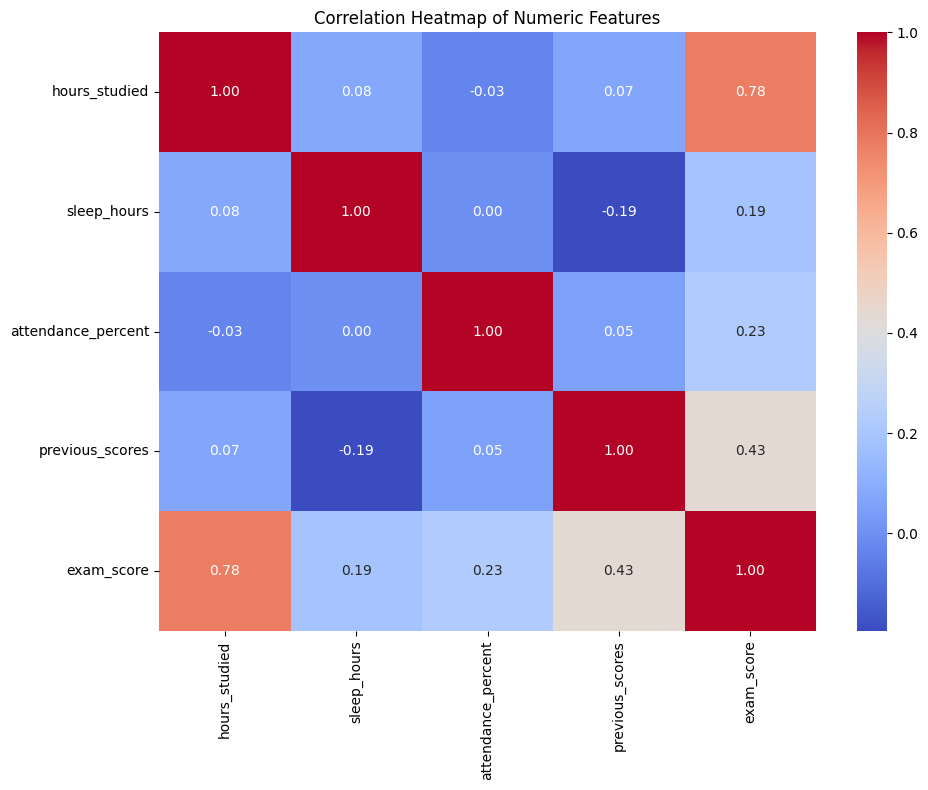

In [11]:
# Reducing the dataframe to only numeric columns for correlation analysis
numeric_df = df.select_dtypes(include=[np.number])

# Correlation Heatmap (only drawn if we have at least 4 numeric columns)
if numeric_df.shape[1] >= 4:
    plt.figure(figsize=(10, 8))
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Heatmap of Numeric Features')
    plt.tight_layout()
    plt.show()
else:
    print('Not enough numeric columns for a correlation heatmap.')

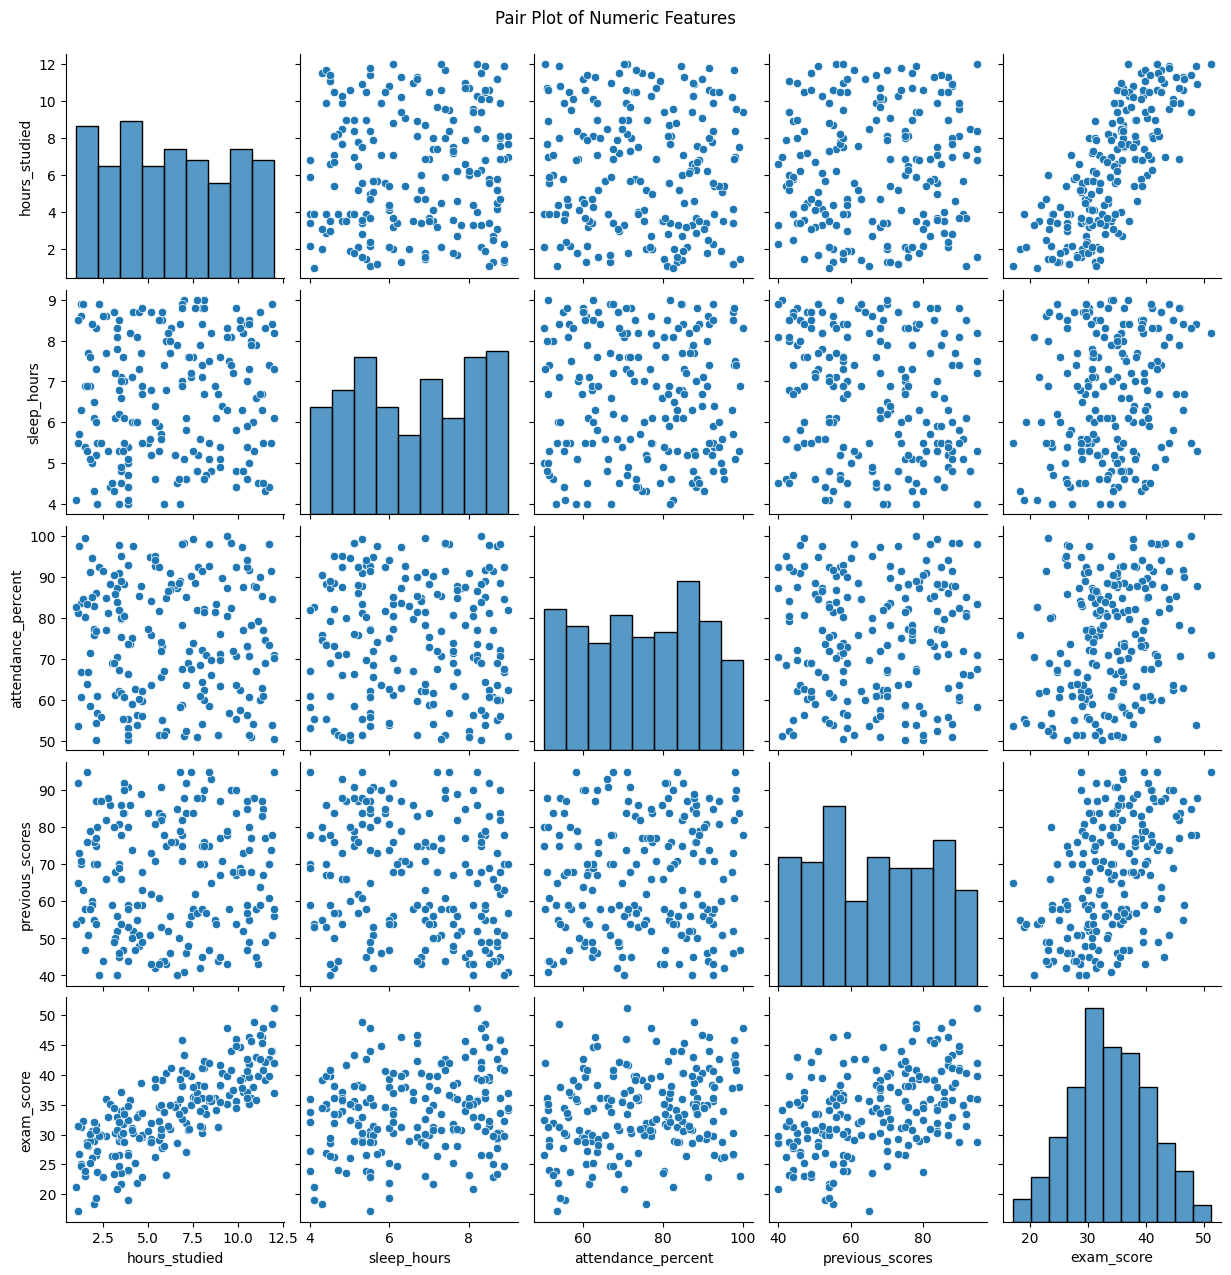

In [12]:
# Pair Plot
sns.pairplot(df[numeric_cols])
plt.suptitle('Pair Plot of Numeric Features', y=1.02)
plt.show()

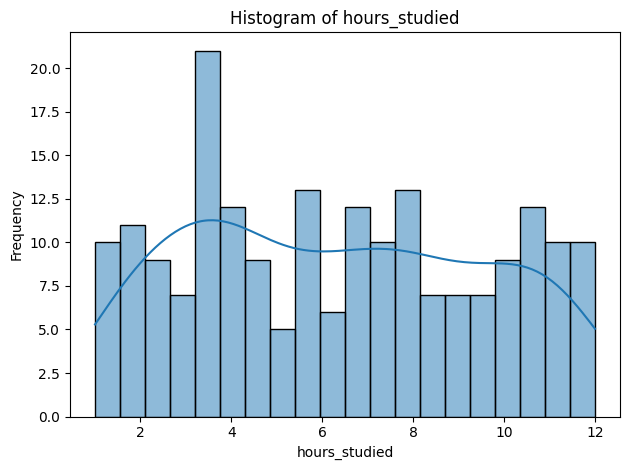

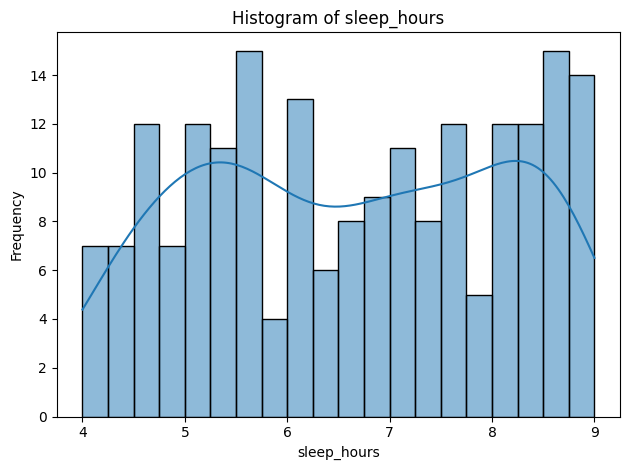

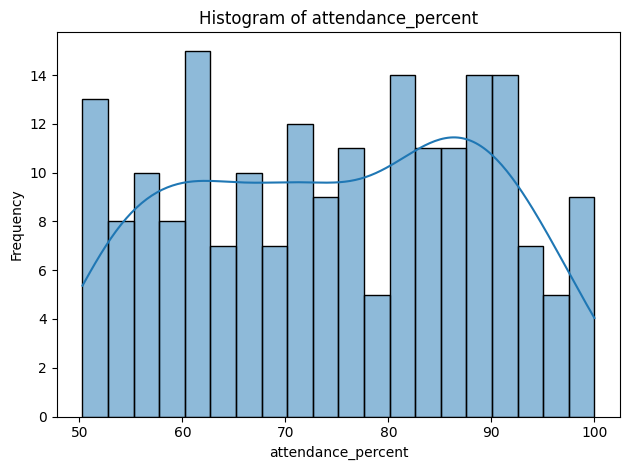

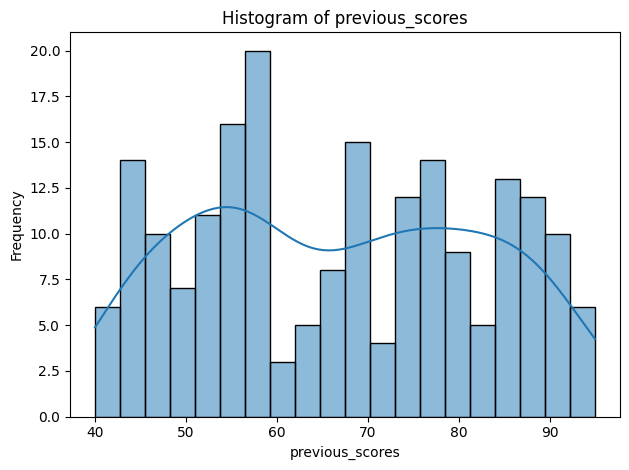

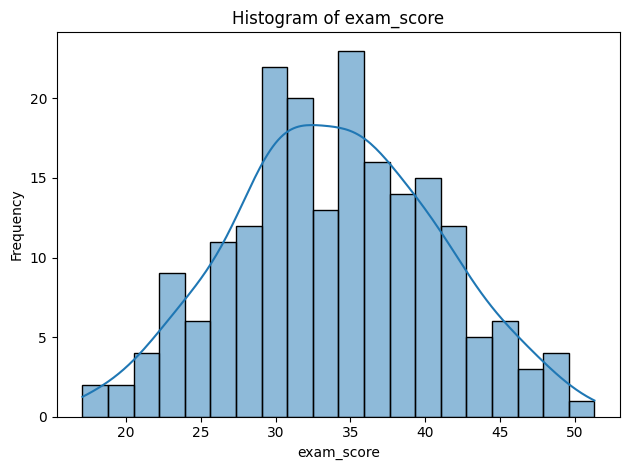

In [13]:
# Histograms for each numeric column
for col in numeric_cols:
    plt.figure()
    sns.histplot(df[col], bins=20, kde=True)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()


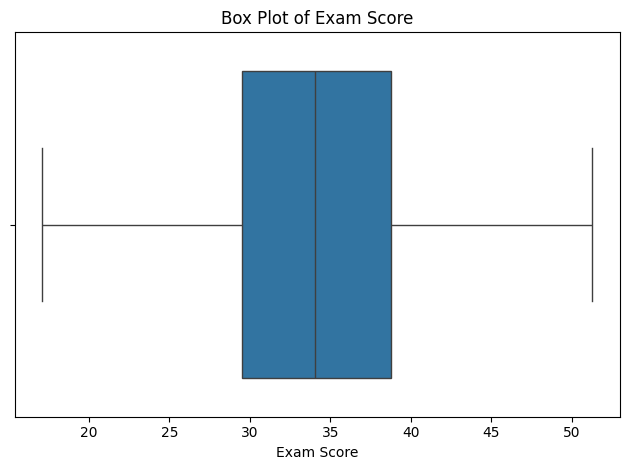

In [14]:
# Box Plot for exam_score to detect outliers
plt.figure()
sns.boxplot(x=df['exam_score'])
plt.title('Box Plot of Exam Score')
plt.xlabel('Exam Score')
plt.tight_layout()
plt.show()

In [20]:
# Define features and target variable for the predictor
features = ['hours_studied', 'sleep_hours', 'attendance_percent', 'previous_scores']
target = 'exam_score'

# Split the dataset into training and testing subsets
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Initialize and train the linear regression model
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [35]:
# Make predictions on the test set
y_pred = lr.predict(X_test)
y_pred

array([28.88607164, 29.68042066, 35.31195586, 31.18044826, 39.44894287,
       41.69158322, 23.96918347, 45.72250896, 41.6529321 , 27.47615681,
       26.09033959, 44.45348162, 27.22577144, 29.33836752, 36.53825172,
       34.75877399, 31.5395367 , 28.52996777, 40.3792585 , 29.84951368,
       21.85245583, 24.08822626, 27.61839558, 27.93331998, 35.96012145,
       43.8081039 , 34.91507705, 28.592239  , 37.57486402, 43.9712545 ,
       27.7683444 , 37.33910217, 37.03824477, 28.28799615, 42.6421297 ,
       21.64648068, 38.42517152, 36.15049022, 44.91531908, 35.47066788])

In [31]:
# Evaluate the model using the R² score
score = r2_score(y_test, y_pred)
print('R² score of the Linear Regression model:', score)

R² score of the Linear Regression model: 0.8140700243640012


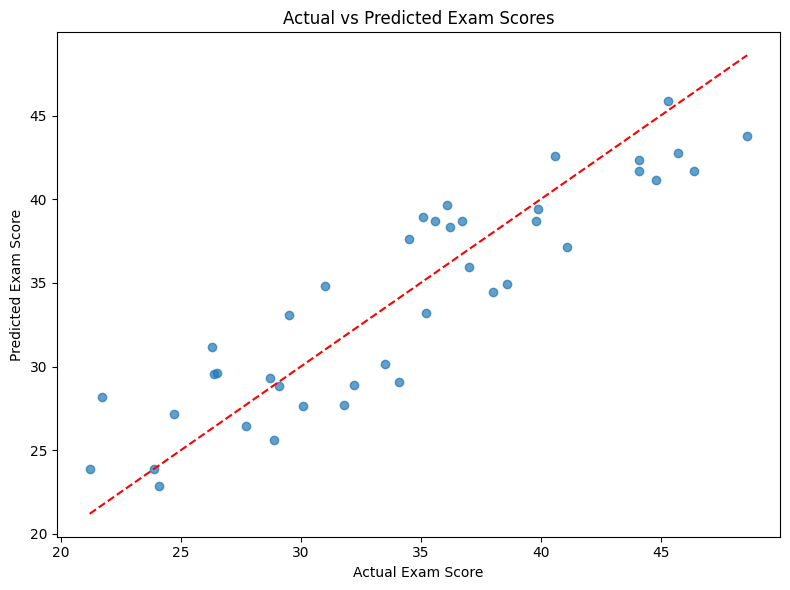

In [48]:
# Plotting the predicted vs actual exam scores
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Exam Score')
plt.ylabel('Predicted Exam Score')
plt.title('Actual vs Predicted Exam Scores')
plt.tight_layout()
plt.show()

In [28]:
from sklearn.ensemble import RandomForestRegressor
# Initialise and train Logistic Regression Model
rf=RandomForestRegressor()
rf.fit(X_train,y_train)

RandomForestRegressor()

In [36]:
# Make prediction on the test set
y_pred=rf.predict(X_test)
y_pred

array([29.294, 29.056, 37.624, 33.065, 39.645, 41.692, 23.869, 45.894,
       41.164, 27.725, 28.193, 41.663, 27.628, 29.643, 38.325, 34.805,
       33.206, 26.476, 38.715, 30.176, 23.893, 25.58 , 29.57 , 28.831,
       38.697, 43.772, 34.449, 28.926, 34.916, 42.755, 27.18 , 38.721,
       35.953, 31.148, 42.356, 22.889, 37.143, 38.934, 42.567, 39.406])

In [40]:
# Evaluate the model using the R² score
score = r2_score(y_test, y_pred)
print('R² score of the Random Forest Regressor model:', score)

R² score of the Random Forest Regressor model: 0.8140700243640012


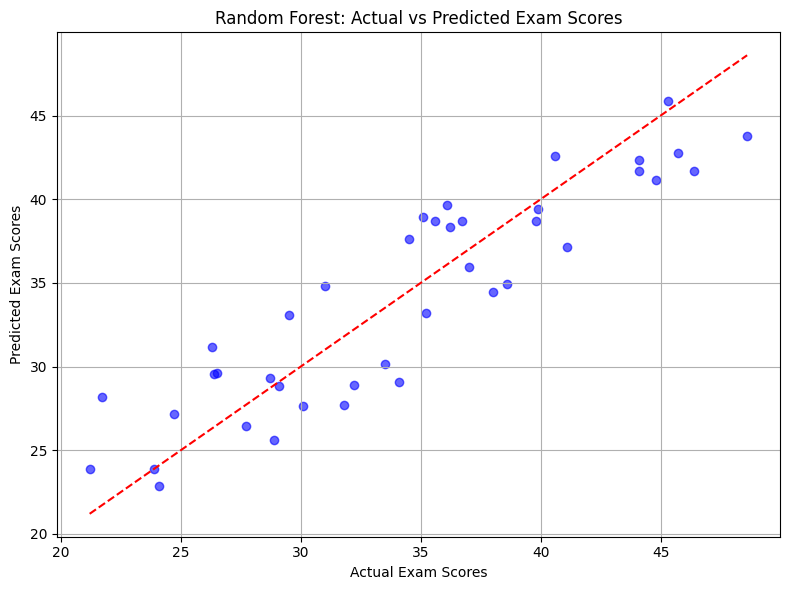

In [46]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Diagonal line
plt.xlabel('Actual Exam Scores')
plt.ylabel('Predicted Exam Scores')
plt.title('Random Forest: Actual vs Predicted Exam Scores')
plt.grid(True)
plt.tight_layout()
plt.show()


In [52]:
import xgboost as xgb
# Initialize XGBoost Regressor
xgb_model = xgb.XGBRegressor()
xgb_model.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [54]:
# Make prediction on the Model
y_pred=xgb_model.predict(X_test)
y_pred

array([29.452877, 29.360716, 37.57454 , 34.023926, 39.508755, 41.38978 ,
       25.641241, 48.411934, 44.45122 , 28.910341, 27.95093 , 39.05829 ,
       26.453463, 29.376822, 36.84325 , 35.8315  , 34.8969  , 25.45972 ,
       39.89722 , 31.28722 , 23.97333 , 22.936468, 30.541014, 29.370693,
       39.2483  , 42.913128, 35.977684, 31.768461, 34.71679 , 41.99115 ,
       29.352646, 37.782715, 36.266945, 33.26888 , 43.542675, 23.287512,
       36.510654, 39.374863, 42.192028, 38.485313], dtype=float32)

In [55]:
# Evaluate the model using the R² score
score = r2_score(y_test, y_pred)
print('R² score of the xgb.XGBRegressor model:', score)

R² score of the xgb.XGBRegressor model: 0.7722470411488805


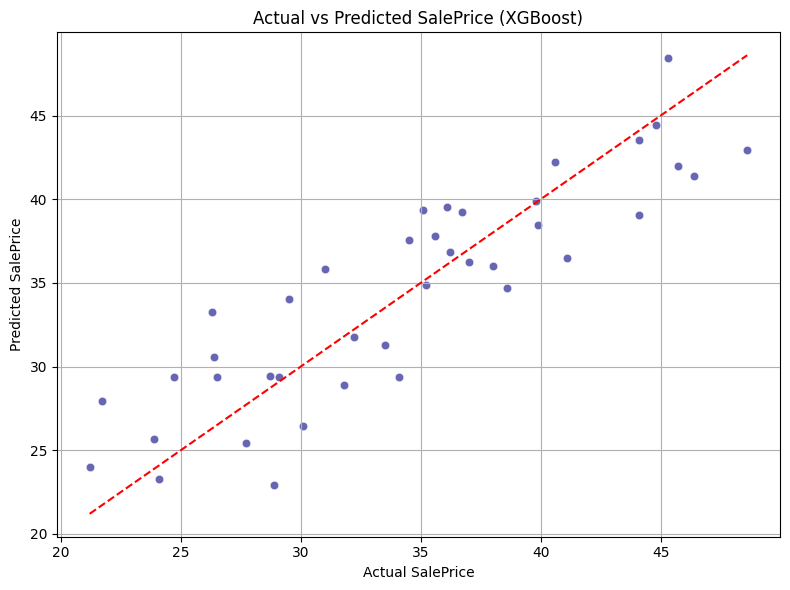

In [56]:
# Plot
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='navy')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Diagonal line
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.title('Actual vs Predicted SalePrice (XGBoost)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [59]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost':xgb.XGBRegressor(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        'R²': r2_score(y_test, y_pred)
    }


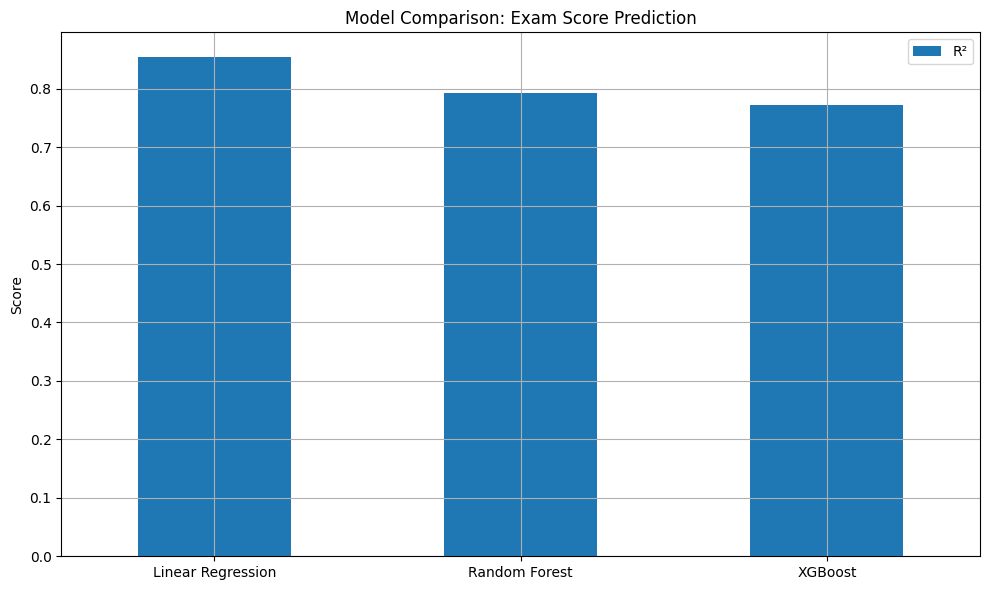

In [60]:
results_df = pd.DataFrame(results).T
results_df.plot(kind='bar', figsize=(10,6))
plt.title('Model Comparison: Exam Score Prediction')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.grid(True)
plt.tight_layout()
plt.show()